# Implicit Funciton toolboox for geophysics

If we can fit a point data to an Implicit Neural Network, we can operate directly on the Neural Network representation.

In [1]:
import random
from pathlib import Path

import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import netCDF4
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

torch.manual_seed(seed := 0)
random.seed(seed)

rng = np.random.default_rng()

if torch.cuda.is_available():
    device = "cuda"

(200, 200, 50)


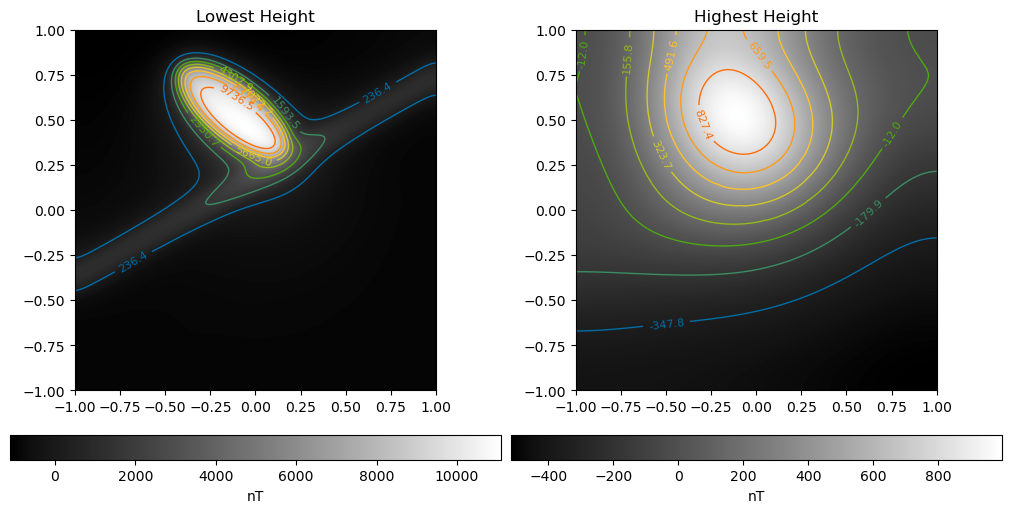

In [2]:
dir_path = Path("/home/luke/PhD/ch3/implicitgeo/data")
default_extent = [-1, 1, -1, 1]


def merge_z_slices(dir_path: str, idx: int = 0, n: int = 50):
    """Merge multiple Noddy forward models into a single 3D array
    For example, create a 200x200x200 volume of synthetic measurements.
    Args:
        dir_path: Path to directory to merge all .mag (and .grv)
        idx: Which model dir index to load
        n: number of files to include, i.e. number of slices
    """

    dir_path = Path(dir_path)

    mag_files = sorted(list(dir_path.glob("*"))[idx].glob("*.mag"))[:n]
    # grv_files = sorted(list(dir_path.glob("*"))[idx].glob("*.grv"))[:n]

    # get x y extent from header
    # _, xlen, ylen, _ = mag_files[0].read_text().splitlines()[3].split()
    # zlen = len(mag_files)

    return np.stack(
        [np.genfromtxt(f, dtype=np.float32, skip_header=8) for f in mag_files], axis=-1
    )


def plt_cntr(u, **kwargs):
    im = plt.imshow(u, origin="lower", cmap=cc.cm.CET_L1, **kwargs)
    cset = plt.contour(
        u,
        np.linspace(u.min(), u.max(), 10),
        linewidths=1,
        cmap=cc.cm.CET_R2,
        **kwargs,
    )
    plt.clabel(cset, inline=True, fmt="%1.1f", fontsize=8)
    plt.colorbar(im, orientation="horizontal", label="nT")


mag_vol = merge_z_slices(dir_path, idx=0)
plt.figure(layout="constrained", figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Lowest Height")
plt_cntr(mag_vol[:, :, 0], extent=default_extent)
plt.subplot(1, 2, 2)
plt.title("Highest Height")
plt_cntr(mag_vol[:, :, -1], extent=default_extent)
print(mag_vol.shape)

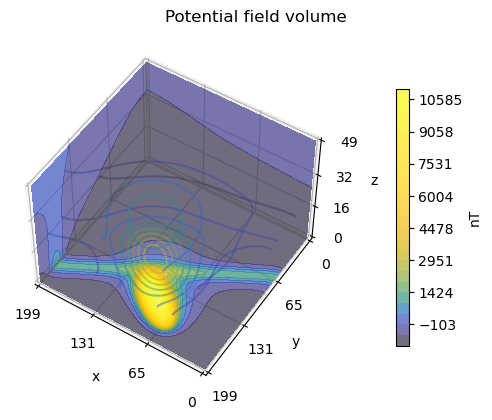

In [3]:
def plt_3d(u, ori="z", levels=25, step=10, **kwargs):
    x, y, z = np.meshgrid(
        np.arange(u.shape[0]),
        np.arange(u.shape[1]),
        np.arange(u.shape[2]),
    )

    kw = dict(
        vmin=u.min(),
        vmax=u.max(),
        cmap=kwargs.get("cmap", cc.cm.CET_L20),
        # norm=colors.PowerNorm(gamma=0.5),
        norm=colors.AsinhNorm(linear_width=kwargs.get("linear_width", 1)),
        levels=np.linspace(u.min(), u.max(), levels),
        alpha=kwargs.get("alpha", 0.1),
    )

    # Create a figure with 3D ax
    if kwargs.get("fig"):
        fig = kwargs.get("fig")
        ax = kwargs.get("ax")
    else:
        fig = plt.figure(figsize=(5, 4), layout="constrained")
        ax = fig.add_subplot(111, projection="3d")
        
    fig.suptitle(kwargs.get("title", "Potential field volume"))

    # Plot contour surfaces
    _ = ax.contourf(
        x[0, :, :],
        u[0, :, :],
        z[0, :, :],
        zdir="y",
        offset=0,
        **{**kw, "alpha": 0.7},
    )
    _ = ax.contourf(
        u[:, -1, :],
        y[:, -1, :],
        z[:, -1, :],
        zdir="x",
        offset=x.max(),
        **{**kw, "alpha": 0.7},
    )
    C = ax.contourf(
        x[:, :, 0],
        y[:, :, 0],
        u[:, :, 0],
        zdir="z",
        offset=z.min(),
        **{**kw, "alpha": 0.7},
    )

    if ori == "z":  # Contour flat in Z
        for i in np.arange(z.min() + step, z.max() + 1, step):
            _ = ax.contour(x[:, :, 0], y[:, :, 0], u[:, :, i], zdir="z", offset=i, **kw)

    elif ori == "x":  # Contour flat in X
        for i in np.arange(x.min() + step, x.max() + 1, step):
            _ = ax.contour(
                u[:, i, :], y[:, -1, :], z[:, -1, :], zdir="x", offset=i, **kw
            )

    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    zmin, zmax = z.min(), z.max()
    ax.set(xlim=[xmin, xmax], ylim=[ymin, ymax], zlim=[zmin, zmax])

    edges_kw = dict(color="0.4", linewidth=1, zorder=1e3)
    ax.plot([xmax, xmax], [ymin, ymax], 0, **edges_kw)
    ax.plot([xmin, xmax], [ymin, ymin], 0, **edges_kw)
    ax.plot([xmax, xmax], [ymin, ymin], [zmin, zmax], **edges_kw)

    ax.set(
        xlabel="x",
        ylabel="y",
        zlabel="z",
        xticks=[int(xmax * i) for i in [0, 0.33, 0.66, 1]],
        yticks=[int(ymax * i) for i in [0, 0.33, 0.66, 1]],
        zticks=[int(zmax * i) for i in [0, 0.33, 0.66, 1]],
    )

    ax.view_init(kwargs.get("elev", 45), kwargs.get("azim", 45), 0)
    ax.set_box_aspect(None, zoom=1)

    fig.colorbar(C, ax=ax, fraction=0.04, pad=0.2, label="nT")

    if kwargs.get("fig"):
        return
        
    plt.show()


plt_3d(mag_vol, ori="z", step=20, elev=50, azim=123, linear_width=1000, cmap=cc.cm.CET_L20, alpha=0.5)

In [4]:
class INRDataset(Dataset):
    """Base class for Implicit Neural Representation Dataset"""

    def __init__(self):
        super().__init__()
        self.coords = None
        self.cells = None

    def __len__(self):
        return 1  # This is an Implicit Function to overfit 1 sample

    def _subsample(self, s: int = 1):
        """Subsample the dataset to reduce RAM usage"""
        if s == 1:
            return
        self.u = self.u[::s, ::s, ::s]

    def _normalise(self, inp, a=-1, b=1):
        """Min-Max Normalise between upper and lower -1 and 1"""
        self.a = a
        self.b = b
        self._min = inp.min()
        self._max = inp.max()
        return (b - a) * ((inp - self._min) / (self._max - self._min)) + a

    def _unnormalise(self, data):
        return (data - self.a) * (
            (self._max - self._min) / (self.b - self.a)
        ) + self._min

    def __getitem__(self, idx):
        if idx > 0:
            raise IndexError("This dataset should always have length 1")
        if self.cells is None or self.coords is None:
            raise ValueError("Dataset has not been init")
            
        return {"coords": self.coords, "cells": self.cells}

In [5]:
class PointData3D(INRDataset):
    """Construct a dataset for SIREN comprising 3D point coordinates
    and point values
    """

    def __init__(self, xyz_dir, idx, subsample=1):
        super().__init__()
        self.xyz_dir = xyz_dir
        self.u = merge_z_slices(self.xyz_dir, idx=idx)
        self._subsample(subsample)
        self.og_shape = self.u.shape
        self.coords = self.get_mgrid()
        self.cells = torch.from_numpy(self.u).contiguous().view(-1, 1)
        self.coords = self._normalise(self.coords)
        self.cells = self._normalise(self.cells)

    def get_mgrid(self):
        tensors = tuple((torch.linspace(-1, 1, steps=s) for s in self.u.shape))
        coords = torch.stack(torch.meshgrid(*tensors, indexing="ij"), dim=-1)
        coords = coords.reshape(-1, len(tensors)).unsqueeze(0)
        return coords



In [6]:
class NCDataset(INRDataset):
    def __init__(self, netcdf_path):
        super().__init__()

        self.netcdf_path = Path(netcdf_path)
        self._load_nc()

    def _load_nc(self):
        ncd = netCDF4.Dataset(self.netcdf_path, "r")
        self.coords = tuple(
            (
                torch.from_numpy(self._normalise(ncd.variables["x"][:])),
                torch.from_numpy(self._normalise(ncd.variables["y"][:])),
                torch.from_numpy(self._normalise(ncd.variables["altitude"][:])),
            )
        )

        self.coords = (
            torch.stack(self.coords, dim=-1)
            .reshape(-1, 3)
            .unsqueeze(0)
            .to(torch.float32)
        )
        
        self.cells = torch.from_numpy(
            self._normalise(ncd.variables["mag_microLevelled"][:])
        )
        self.cells = self.cells.contiguous().view(-1, 1)

In [7]:
# SIREN

if use_siren := 1:
    from models import Siren

    siren_lr = 5e-4

    model_siren = Siren(
        in_features=3,
        out_features=1,
        hidden_features=256,
        hidden_layers=2,
        outermost_linear=True,
    )
else:
    model_siren = None

print(model_siren)

Siren(
  (net): Sequential(
    (0): SineLayer(
      (linear): Linear(in_features=3, out_features=256, bias=True)
    )
    (1): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (2): SineLayer(
      (linear): Linear(in_features=256, out_features=256, bias=True)
    )
    (3): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [8]:
# Wire
# HP from https://github.com/vishwa91/wire/blob/main/wire_ct.py

if use_wire := 0:
    from models import get_INR as wire

    wire_lr = 2e-3

    model_wire = wire(
        nonlin="wire2d",  # wire2d
        in_features=3,
        out_features=1,
        hidden_features=256,
        hidden_layers=2,
        first_omega_0=10.0,
        hidden_omega_0=10.0,
        scale=10.0,
        pos_encode=False,
        sidelength=None,  # only for pos_encode
    )
else:
    model_wire = None

print(model_wire)

None


  0%|          | 0/1000 [00:00<?, ?it/s]

Step 999, Total loss 0.000058


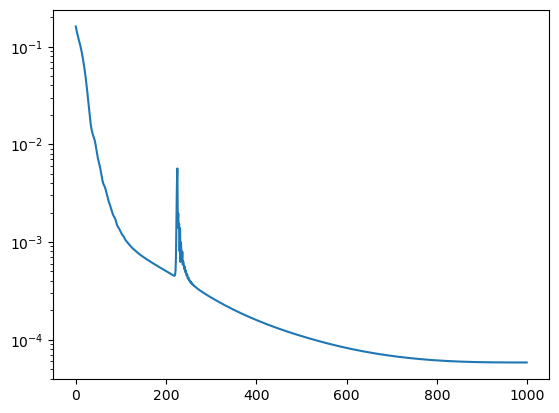

In [9]:
if use_siren:
    model = model_siren.to(device, non_blocking=True)
    lr = siren_lr
elif use_wire:
    model = model_wire.to(device, non_blocking=True)
    lr = wire_lr

# dataset = PointData3D("/home/luke/PhD/ch3/implicitgeo/data", 0, subsample=5)
dataset = NCDataset("/home/luke/PhD/ch3/implicitgeo/data/P864-line-magnetic-AWAGS_MAG_2010.nc")
# dataloader = DataLoader(dset, batch_size=1, pin_memory=True, num_workers=0)
# 12 GB GPU RAM suits ~100_000 elements

train_opts = dict(
    lr=lr,
    total_steps=1000,  # steps = epochs in INR
    summary_steps=[999],
    device=device,
    use_amp=False,
)


def train(model, dataset, opt):
    model.train()
    losses = []

    optim = torch.optim.Adam(lr=opt["lr"], params=model.parameters())
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optim,
        steps_per_epoch=1,
        epochs=opt["total_steps"],
        max_lr=opt["lr"],
    )

    d = dataset[0]
    inp_coords = d["coords"].to(device, non_blocking=True)
    gt_cells = d["cells"].to(device, non_blocking=True)

    for step in tqdm(range(opt["total_steps"])):
        with torch.amp.autocast(
            opt["device"], dtype=torch.float16, enabled=opt["use_amp"]
        ):
            pred_cells, coords = model(inp_coords)
            loss = ((pred_cells - gt_cells) ** 2).mean()
            losses.append(loss.item())

        if step in opt["summary_steps"]:
            print("Step %d, Total loss %0.6f" % (step, loss))
            plt.subplot(1, 1, 1)
            plt.plot(losses)
            plt.semilogy()

        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()
        sched.step()

    return model


model = train(model, dataset, train_opts)

In [10]:
i = 0
height = np.linspace(
    dataset.coords[0, 0, 0],
    dataset.coords[-1, -1, -1],
    dataset.vol.shape[-1],
)[i]
inp_coords, gt_cells = dataset[0]
inp_coords, gt_cells = inp_coords.to(device), gt_cells.to(device)

pred_cells, coords = model(inp_coords)
# img_grad = gradient(model_output, coords)
u = pred_cells.detach().cpu().view(dataset.og_shape)
u = dataset._unnormalise(u).numpy()
#     img_laplacian = laplace(model_output, coords)
plt.figure(constrained_layout=True, figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"GT, Normalised Height slice {height}")
plt_cntr(dataset.vol[:, :, i], extent=default_extent)
plt.subplot(1, 2, 2)
plt.title(f"INR, Normalised Height slice {height}")
plt_cntr(u[:, :, i], extent=default_extent)

AttributeError: 'NCDataset' object has no attribute 'vol'

tensor(-0.4837)


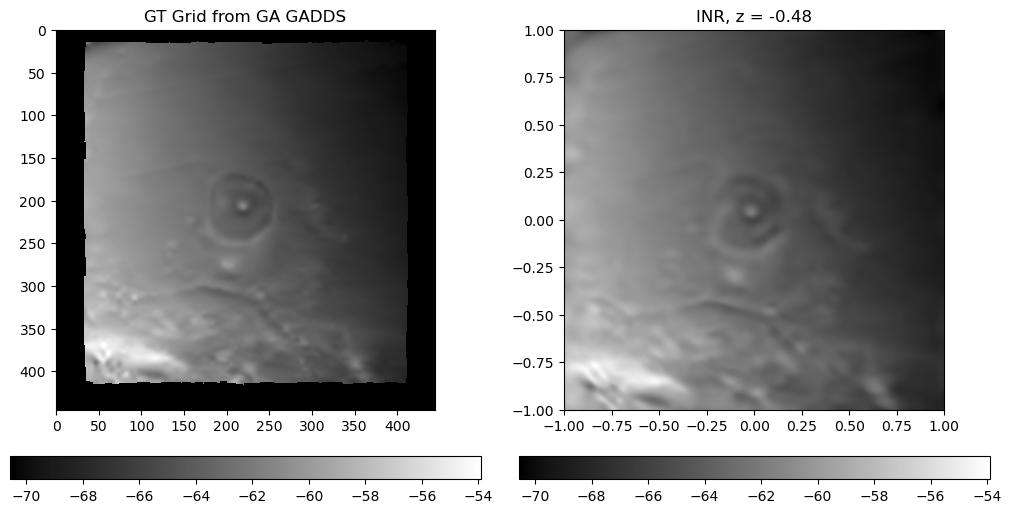

In [29]:
i = 0
h, w, c = (500, 500, 1)
x_r, y_r, z_r = (1, 1, 1)
xy_mod = 1
z_mod = -dataset[0]["coords"][0,:,2].mean()

tensors = tuple(
    (
        torch.linspace(-x_r, x_r, steps=h) * xy_mod,
        torch.linspace(-y_r, y_r, steps=w) * xy_mod,
        torch.linspace(-z_r, z_r, steps=c) * z_mod,
    )
)

coords = torch.stack(torch.meshgrid(*tensors, indexing="ij"), dim=-1)
coords = coords.reshape(-1, len(tensors)).unsqueeze(0).to(torch.float32)
coords = coords.to("cuda", non_blocking=True)

new_u, _ = model(coords)
new_u = new_u.detach().cpu().view((h, w, c))
new_u = dataset._unnormalise(new_u).rot90().numpy()

ax_args = dict(cmap=cc.cm.CET_L1, vmin=new_u[:, :, i].min(), vmax=new_u[:, :, i].max())

plt.figure(constrained_layout=True, figsize=(10, 5))
# plt.subplot(1, 2, 1)
# plt.title(f"GT, z = {(torch.linspace(-z_r, z_r, steps=c))[i]}")
# plt_cntr(dataset.vol[:, :, i], extent=[-x_r, x_r, -y_r, y_r])
import tifffile
plt.subplot(1, 2, 1)
plt.title(f"GT Grid from GA GADDS")
tif = tifffile.imread(r"/home/luke/PhD/ch3/implicitgeo/data/P864-grid-tmi.tif")
plt.imshow(tif, **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 2, 2)
plt.title(f"INR, z = {(torch.linspace(-z_r, z_r, steps=c) * z_mod)[i]:0.2f}")
plt.imshow(
    new_u[:, :, i], extent=[-x_r * xy_mod, x_r * xy_mod, -y_r * xy_mod, y_r * xy_mod],
    **ax_args
)
plt.colorbar(orientation="horizontal")
print(tensors[2][i])

In [ ]:
plt_3d(new_u, ori="x", step=1, elev=15, azim=123, linear_width=1000, alpha=0.03)

Explicit function: $$u(x,y,z) = \sin(x+y+z) + \cos(x-y-z)$$

Explicit x, y, z partial derivatives:
$$\frac{\partial{u(x,y,z)}}{\partial{x}} = \cos(x+y+z) - \sin(x-y-z)$$ 
$$\frac{\partial{u(x,y,z)}}{\partial{y}} = \cos(x+y+z) + \sin(x-y-z)$$
$$\frac{\partial{u(x,y,z)}}{\partial{z}} = \cos(x+y+z) + \sin(x-y-z)$$

In [ ]:
## Custom Function sample:
def cust_fn(d=200, a=1, l=1):
    x, y, z = np.meshgrid(
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        indexing="xy",
    )
    u = a * (np.sin(x + y + z) + np.cos(x - y - z))
    return (x, y, z, u)


def cust_fn_grad(d=200, a=1, l=1):
    x, y, z = np.meshgrid(
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        indexing="xy",
    )
    dudx = a * (np.cos(x + y + z) - np.sin(x - y - z))
    dudy = a * (np.sin(x - y - z) + np.cos(x + y + z))
    dudz = a * (np.sin(x - y - z) + np.cos(x + y + z))

    return (dudx, dudy, dudz)

In [ ]:
x, y, z, u = cust_fn(d=50, a=1, l=10)
dudx, dudy, dudz = cust_fn_grad(d=50, a=1, l=10)

In [ ]:
plt_3d(u, ori="x", step=10, elev=45, azim=135, linear_width=1)

In [ ]:
fig = plt.figure(figsize=(20, 5))
opts = dict(
    ori="x", step=10, elev=45, azim=135, linear_width=1, fig=fig, cmap=cc.cm.CET_L1
)

plt_3d(dudx, **opts, ax=fig.add_subplot(231, projection="3d"))
plt_3d(dudy, **opts, ax=fig.add_subplot(232, projection="3d"))
plt_3d(dudz, **opts, ax=fig.add_subplot(233, projection="3d"))
# plt_3d(dudx, **opts, ax=fig.add_subplot(234, projection="3d"))
# plt_3d(dudy, **opts, ax=fig.add_subplot(235, projection="3d"))
# plt_3d(dudz, **opts, ax=fig.add_subplot(236, projection="3d"))

# TODO

So we've established that an Implicit function such as SIREN can learn a grid extent quite well.  
Now we want to calculate the gradients (Jacobian) using the network.  
We do this as a calculation of the gradients between the model inputs (x,y) and the model output (u) which is the TMI at that x,y point.

There are several ways to calculate the Jacobian:  
1. `torch.autograd.grad`
1. `torch.autograd.functional.jacobian(vectorize=True)`
1. `functorch.jacrev`

https://github.com/pytorch/pytorch/issues/23475#issuecomment-946927242

We want the Jacobian: $$J(x,y) = [\frac{\partial{u(x,y)}}{\partial{x}}, \frac{\partial{u(x,y)}}{\partial{y}}]$$

Where $$ u = f(x,y)\,,\, f:R^2 \to R^1$$
This is the special case where _the Jacobian matrix reduces to the row vector $${\displaystyle \nabla ^{\mathrm {T} }f}$$ this row vector of all first-order partial derivatives of f is the transpose of the gradient of f $${\displaystyle \mathbf {J} _{f}=\nabla ^{T}f}. $$_



In [ ]:
def gradient(u, xyz, grad_outputs=None):
    if grad_outputs is None:
        grad_outputs = torch.ones_like(u)
    grad = torch.autograd.grad(u, [xyz], grad_outputs=grad_outputs, create_graph=True)[
        0
    ]
    return grad


def divergence(u, xyz):
    div = 0.0
    for i in range(u.shape[-1]):
        div += torch.autograd.grad(
            u[..., i], xyz, torch.ones_like(u[..., i]), create_graph=True
        )[0][..., i : i + 1]
    return div


def laplace(u, xyz):
    grad = gradient(u, xyz)
    return divergence(grad, xyz)


def s_jacobian(u, xyz):
    """jacobian of u wrt x"""
    meta_batch_size, num_observations = u.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, u.shape[-1], xyz.shape[-1]).to(
        u.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(u.shape[-1]):
        # calculate dydx over batches for each feature value of y
        u_flat = u[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            u_flat, xyz, torch.ones_like(u_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status

In [ ]:
## Simple method for "Gradient", torch.autograd.grad
## The gradient is a special case of the Jacbian, when the function is scalar
## https://math.stackexchange.com/questions/1519367/difference-between-gradient-and-jacobian

model_input, gt_cells = dataset[0]
model_input.requires_grad_(True)
model_input, gt_cells = model_input.to(device), gt_cells.to(device)

model_output, _ = model(model_input)
model_output = dataset._unnormalise(model_output)
# model_input = dset._unnormalise(model_input)

grad = torch.autograd.grad(
    outputs=model_output,
    inputs=[model_input],
    grad_outputs=torch.ones_like(model_output),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
# grad = [grad[0]]
# print(f"{grad[0].shape = }")

# grad2 = torch.autograd.grad(
#     outputs=[grad[0]],
#     inputs=[model_input],
#     grad_outputs=torch.ones_like(grad[0]),
#     create_graph=True,
#     retain_graph=True,
#     allow_unused=True,
# )
# print(f"{grad2[0].shape = }")

dx, dy = grad.detach()[0].reshape(dataset.s, dataset.s, 2).permute(2, 0, 1).cpu().numpy()

plt.figure(constrained_layout=True, figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("dy")
plt.imshow(dx, cmap=cc.cm.CET_L1, origin="lower")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("dx")
plt.imshow(dy, cmap=cc.cm.CET_L1, origin="lower")
plt.colorbar()

In [ ]:
xmin = dudx.min()
xmax = dudx.max()
ymin = dudy.min()
ymax = dudy.max()

plt.figure(constrained_layout=True, figsize=(10, 10))
plt.subplot(221)
plt.title("Analytical dudx")
plt_cntr(dudx)
plt.subplot(222)
plt.title("Implicit dudx")
plt.imshow(dx, origin="lower", cmap=cc.cm.CET_L1, vmin=xmin, vmax=xmax)
plt.colorbar()
plt.subplot(223)
plt.title("Analytical dudy")
plt_cntr(dudy)
plt.subplot(224)
plt.title("Implicit dudy")
plt.imshow(dy, origin="lower", cmap=cc.cm.CET_L1, vmin=ymin, vmax=ymax)
plt.colorbar()

In [ ]:
def gradients(pred_u, xy_coord):
    """Compute the xx and yy gradients of the Implicit Function
    When trained, inputs of (x,y) coords to a Siren model (F) return u.
    Generally, this is u = F(x,y)
    """
    return (
        torch.autograd.grad(
            outputs=pred_u,
            inputs=[xy_coord],
            grad_outputs=torch.ones_like(pred_u),
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )[0]
        .detach()
        .reshape(dset.s, dset.s, 2)
        .permute(2, 0, 1)
        .cpu()
        # .numpy()
    )


# Below references are per Blakely, R. J. 1996
# _Potential Theory in Gravity and Magnetic Applications_
# Cambridge University Press


def horizontal_gradient(dudy, dudx):
    """Horizontal Gradient, eqn 12.49"""
    # return torch.sqrt(dudx ** 2 + dudy ** 2)
    return torch.dstack((dudy, dudx)).norm(dim=-1, p="fro")


def upward_continuation():
    """Upward Continuation, eqn 12.4
    It would be interesting to include u in the coords, and predict this
    """
    # (dz / 2 * pi) * double integral (output_xyz0) / ((x-x')^2 + (y-y')^2 + (dz**2))**(3/2) dxdy

    return NotImplementedError


def downward_continuation(du):
    """Downward Continuation, eqn 12.5
    args:
        - du: vertical distance to downward continue



    """

    return NotImplementedError


def vertical_derivative(order=1):
    """Vertical Derivative, eqn 12.17
    Args:
        order (int): Order of derivative, e.g. 2 for 2VD

    """
    return NotImplementedError

In [ ]:
pred_u, xy_coord = img_siren(model_input)
dudy, dudx = gradients(pred_u, model_input)
horiz_g = horizontal_gradient(dudy, dudx)

In [ ]:
plt.imshow(horiz_g, cmap=cc.cm.CET_L1, origin="lower")
plt.title("Horizontal Gradient")

In [ ]:
crop = dset.original_shape
# w,e,s,n = (0, crop[-2], 0, crop[-1])
w, e, s, n = zoom

In [ ]:
import matplotlib.colors as colors

fig, axs = plt.subplots(3, 2, layout="constrained", figsize=(10, 12))
plt.suptitle(f"Horizontal Derivatives - {sample.stem}")
plt_opts = dict(origin="upper", cmap=cc.cm.CET_L1)
[[axg, axp], [axx, axy], [axh, axoff]] = axs

axg.set_title(r"Original TMI Grid")
caxi = axg.imshow(
    dset.original_grid.squeeze()[s:n, w:e], cmap=cc.cm.CET_L1, origin="lower"
)
plt.colorbar(mappable=caxi, ax=axg, label=r"nT", location="bottom")

axp.set_title(r"Learnt TMI Grid")
caxp = axp.imshow(
    pred_u.detach().cpu().view(dset.s, dset.s).squeeze()[s:n, w:e], cmap=cc.cm.CET_L1
)
plt.colorbar(mappable=caxp, ax=axp, label=r"nT", location="bottom")

axh.set_title(r"Horizontal gradient")
caxh = axh.imshow(horiz_g[s:n, w:e], cmap=cc.cm.CET_L1, vmin=0, vmax=10)
plt.colorbar(mappable=caxh, ax=axh, label=r"nT/cell", location="bottom")

axx.set_title(r"$\delta$u$\delta$x")
caxx = axx.imshow(dudx[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxx, ax=axx, label=r"nT/cell", location="bottom")

axy.set_title(r"$\delta$u$\delta$y")
caxy = axy.imshow(dudy[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxy, ax=axy, label=r"nT/cell", location="bottom")

# norm = colors.LogNorm(vmin=0.1, vmax=60)
axoff.axis("off")

for ax in axs.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")

In [ ]:
# ## SPARE BITS###


# # from functorch import vmap, vjp, jacrev

# # vmap(jacrev(img_siren))(model_input)
# ###

# j = (dudx, dudy) = torch.autograd.functional.jacobian(lambda t: img_siren(t), model_input)#, vectorize=True)
# ###

# ## Sitzmann et al. method (non vectorised)
# meta_batch_size = pred_u.shape[0]  # only 1 tile
# num_observations = pred_u.shape[1]  # Num XYZ points,
# out_vecs = pred_u.shape[-1]  # num output channels, 1
# in_ch = xy_coord.shape[-1]  # num input channels, 2

# jac = torch.zeros(meta_batch_size, num_observations, out_vecs, in_ch).to(
#     pred_u.device
# )  # (meta_batch_size*num_points, 2, 2)
# for vec in range(out_vecs):
#     # calculate dydx over batches for each feature value of y
#     y_flat = pred_u[..., vec].view(-1, 1)
#     jac[:, :, vec, :] = torch.autograd.grad(
#         y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True
#     )[0]

# ###

# jac2 = jac.squeeze().reshape(200,200,2).permute(2,0,1)[1]
# plt.imshow(jac2.detach().cpu().numpy())
# plt.colorbar()
# ###


# from functorch import vmap, vjp, jacrev

# def f(x):
#     return img_siren(x)

# j = jacrev(f)(model_input.squeeze())

# print(model_input.squeeze().shape)
# print(f"{j[0].shape=}")
# print(f"{j[1].shape=}")

# ###

# ## As of pytorch 1.13, we can now use functorch operations
# ## https://pytorch.org/functorch/stable/notebooks/jacobians_hessians.html

# # from functorch import vmap, vjp, jacfwd, jacrev
# # torch.manual_seed(0)

# # img_siren

# # m = model_input.clone().requires_grad_()

# # cotangents = torch.eye(m.shape[1])
# # _, vjp_fn = vjp((img_siren), m)
# # vmap(vjp_fn)(cotangents)

# # # ft_jacobian = jacrev(img_siren, argnums=(0,))(m)

# # # ft_jacobian = vmap(jacrev(img_siren, argnums = 0), in_dims=(None, 0, None))
# # # btach_jac = ft_jacobian( )

# # model_output, coords = img_siren(model_input)
# # print(f"{model_input.shape=}")
# # print(f"{img_siren(model_input)[0].shape=}")
# # print(f"{img_siren(model_input)[1].shape=}")

# # j = torch.autograd.functional.jacobian(lambda x: img_siren(x)[0], model_input, vectorize=True)
# # j2 = torch.diagonal(j, offset=0, dim1=0, dim2=2)
# # j3 = j2.permute(2,0,1)

# # j2.shape
# # j.squeeze()[1].reshape(s, s, 2).shape